In [19]:
import sys
sys.path.append('../')
from src.models.train import train_all_models, split_data
from src.features.features_engineering import feature_engineering
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np
import scipy.stats as stats
from sklearn.metrics import confusion_matrix

import pandas as pd

df = pd.read_csv("../data/raw/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")

df_model = feature_engineering(df)

### Definimos X y Y

#### Variables para el modelado
Estas variables representan una correlacion significativa con el target, tanto positivamente como negativamente. Es posible que se cambien o se incluyan mas en el modelo.

In [20]:
features = [
    'risk_score',
    'repayment_delay_days',
    'missed_payments',
    'customer_segment_Medium Risk',
    'income_group_Alto',
    'credit_group_Regular',
    'customer_segment_Low Risk',
    'employment_type_Self-Employed',
    'credit_group_Bueno',
    'dti_group_Medio'
]

In [21]:
features_completo = [
    'risk_score',
    'repayment_delay_days',            
    'missed_payments',                  
    'dti_group_Medio',                  
    'employment_type_Unemployed',       
    'employment_type_Student',          
    'income_group_Medio',               
    'dti_group_Alto',                   
    'bnpl_installments',                
    'age_group_Joven_Adulto',           
    'app_usage_frequency',              
    'age_group_Adulto',                
    'purchase_group_Medio',            
    'age_group_Mayor',                 
    'credit_group_Excelente',          
    'credit_group_Bueno',              
    'employment_type_Self-Employed',  
    'customer_segment_Low Risk',       
    'credit_group_Regular',           
    'income_group_Alto',               
    'customer_segment_Medium Risk'   
]

In [22]:
X_full = df_model.drop("default_flag", axis=1)
X1 = df_model[features]
X2 = df_model[features_completo]
y = df_model['default_flag']

### Entrenamos los modelos

In [23]:
feature_sets = {
    "full": X_full,
    "features": X1,
    "features_completo": X2
}

models = train_all_models(feature_sets, y)


 DATASET: full 

--- Logistic Regression ---
Accuracy: 0.6375
Recall: 0.6812
Precision: 0.5337
F1-score: 0.5985
ROC-AUC: 0.7387

--- Overfitting: Logistic Regression ---
Train ROC-AUC: 0.7514
Test ROC-AUC: 0.7387
Diferencia: 0.0127

--- Random Forest ---
Accuracy: 0.6044
Recall: 0.881
Precision: 0.5008
F1-score: 0.6385
ROC-AUC: 0.7627

--- Overfitting: Random Forest ---
Train ROC-AUC: 0.7772
Test ROC-AUC: 0.7627
Diferencia: 0.0145

--- XGBoost ---
Accuracy: 0.6584
Recall: 0.6362
Precision: 0.5613
F1-score: 0.5964
ROC-AUC: 0.748

--- Overfitting: XGBoost ---
Train ROC-AUC: 0.9703
Test ROC-AUC: 0.748
Diferencia: 0.2224

--- XGBoost-Ultra ---
Accuracy: 0.6506
Recall: 0.6812
Precision: 0.5479
F1-score: 0.6073
ROC-AUC: 0.763

--- Overfitting: XGBoost-Ultra ---
Train ROC-AUC: 0.8163
Test ROC-AUC: 0.763
Diferencia: 0.0533

 DATASET: features 

--- Logistic Regression ---
Accuracy: 0.638
Recall: 0.6839
Precision: 0.5341
F1-score: 0.5998
ROC-AUC: 0.7403

--- Overfitting: Logistic Regression --

Tabla general

In [24]:
rows = []

for dataset, models_dict in models.items():
    for model_name, info in models_dict.items():

        row = {
            "dataset": dataset,
            "model": model_name,
            **info["metrics"],
            **info["overfitting"]
        }

        rows.append(row)

df_results = pd.DataFrame(rows)
df_results.sort_values("recall", ascending=False)

,dataset,model,modelo,accuracy,recall,precision,f1,roc_auc,train_auc,test_auc,overfitting_gap
5,features,rf,Random Forest,0.606506,0.886243,0.502249,0.641148,0.760209,0.772588,0.760209,0.012380
1,full,rf,Random Forest,0.604407,0.880952,0.500752,0.638543,0.762717,0.777178,0.762717,0.014461
9,features_completo,rf,Random Forest,0.605456,0.880952,0.501506,0.639155,0.762839,0.777408,0.762839,0.014569
7,features,xgb_ultra,XGBoost-Ultra,0.658447,0.720899,0.553299,0.626077,0.766207,0.805401,0.766207,0.039194
11,features_completo,xgb_ultra,XGBoost-Ultra,0.663694,0.702381,0.560718,0.623605,0.766384,0.816741,0.766384,0.050356
6,features,xgb,XGBoost,0.655299,0.695767,0.551941,0.615565,0.755022,0.885907,0.755022,0.130884
4,features,logistic,Logistic Regression,0.637985,0.683862,0.534091,0.599768,0.740326,0.750073,0.740326,0.009748
0,full,logistic,Logistic Regression,0.637461,0.681217,0.533679,0.598489,0.738666,0.751369,0.738666,0.012704
3,full,xgb_ultra,XGBoost-Ultra,0.650577,0.681217,0.547872,0.607311,0.762968,0.816289,0.762968,0.053322
8,features_completo,logistic,Logistic Regression,0.636411,0.678571,0.532710,0.596859,0.739103,0.751210,0.739103,0.012107


* La regresión logística tanto para features como para features-completo no presenta overfitting. Sin emabrgo se presenta mejor rendimiento en features-completo
* Random Forest: En este caso se analiza que en ambos casos no hay un overfitting lo que supone buen poder de predicción del modelo bajo la métrica de recall
* XGBoost: Para features y features-completo encontramos que hay leve overfitting
* XGBoost-Ultra: En este caso encontramos que no hay overfitting en ningún caso


Para mí,ahí el mejor va siendo XGB-hiper con features (viendo recall y precisión), no sé tú que opines
Y según yo, las variables que dejéen features completo están haciendo ruido

### Curvas de Aprendizaje por modelo

In [25]:
def curva_aprendizaje(modelos, X, y):

    for nombre, model in modelos.items():

        plt.figure(figsize=(8,5)) 

        train_sizes, train_scores, test_scores = learning_curve(
            model,
            X, y,
            cv=5,
            scoring='recall',
            train_sizes=np.linspace(0.1, 1.0, 5),
            n_jobs=1
        )

        train_mean = train_scores.mean(axis=1)
        test_mean = test_scores.mean(axis=1)

        plt.plot(train_sizes, train_mean, '--', label='Train')
        plt.plot(train_sizes, test_mean, label='Test')

        plt.title(f"Curva de aprendizaje - {nombre}")
        plt.xlabel("Tamaño del entrenamiento")
        plt.ylabel("Recall")
        plt.legend()
        plt.grid()

        plt.show()

In [26]:
neg = (y == 0).sum()
pos = (y == 1).sum()
scale = neg / pos

In [27]:

modelos_features = {
    "Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight='balanced',
            max_iter=2000
        ))
    ]),
    "RF": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    "XGB": xgb.XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale,
        random_state=42
    ),
    "XGB-Ultra": xgb.XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

#### Utilizando Variables full

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\pipeline.py", line 475, in fit
    self._final_estimator.fit(Xt, y, 

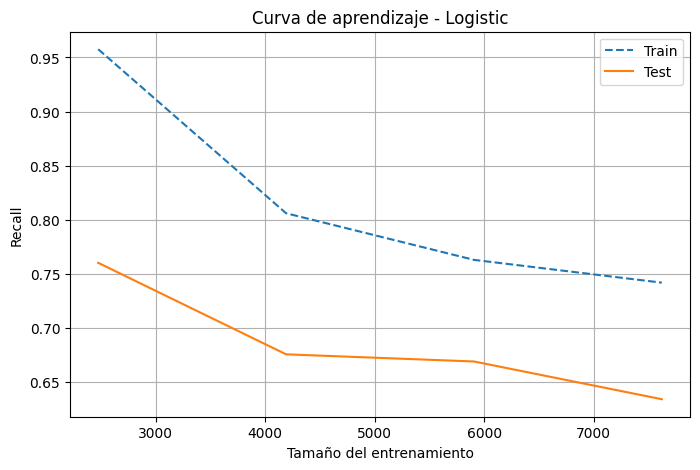

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\u

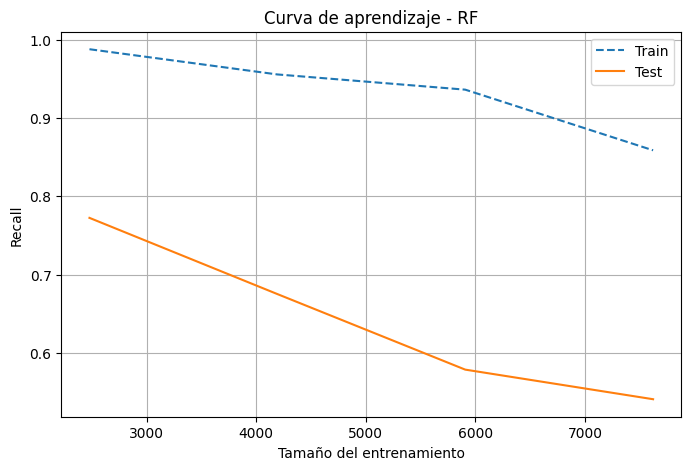

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\u

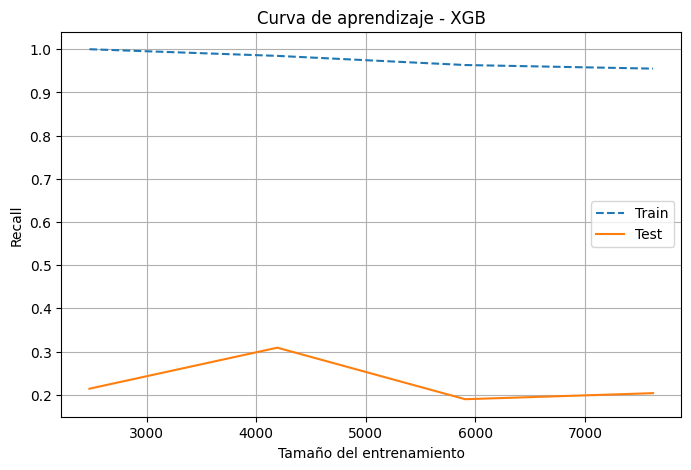

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\u

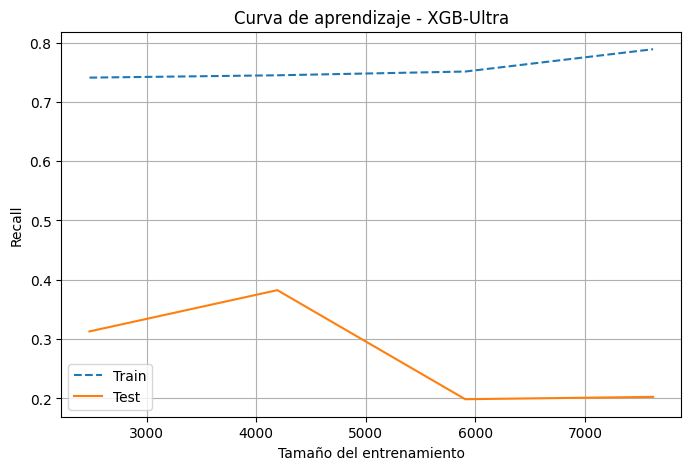

In [28]:
curva_aprendizaje(modelos_features, X_full, y)

En primer lugar, utilizando todas las variables, el modelo de regresión logística muestra que las métricas de entrenamiento y prueba son similares, lo que indica que el modelo no está sobreajustado. Sin embargo, el recall es bajo, lo que sugiere que el modelo no está capturando bien los casos positivos (default). Las curvas comienzan a decrecer de manera que, aunque se le esté dando más datos, el modelo no los aprovechará.

Con respecto a Random Forest, se observa una conducta distinta, pues comienza con un recall bastante alto con los primeros datos y comienza a estabilizarse antes de los 3000 datos. Algo muy positivo, pues el modelo está balanceado y mejora su capacidad a medida que se le introducen datos.

El modelo de XGBoost está presentando una curva de entrenamiento casi perfecta tan solo cuando se le inyectan los primeros datos, donde podemos deducir que hay un posible sobreajuste, debido a que en el test para datos nuevos tiene un bajo recall, haciendo que el modelo esté memorizando los datos, pero no está entendiéndolos.

Por otro lado, el modelo de XGBOOST Ultra presenta una situación parecida a la anterior en el inicio, pero en este modelo sí tratan de estabilizarse al mandarles más datos; de igual forma, el recall sigue siendo un poco bajo para lo que queremos.

### Usando variables seleccionadas con mayor correlacion 

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\pipeline.py", line 475, in fit
    self._final_estimator.fit(Xt, y, 

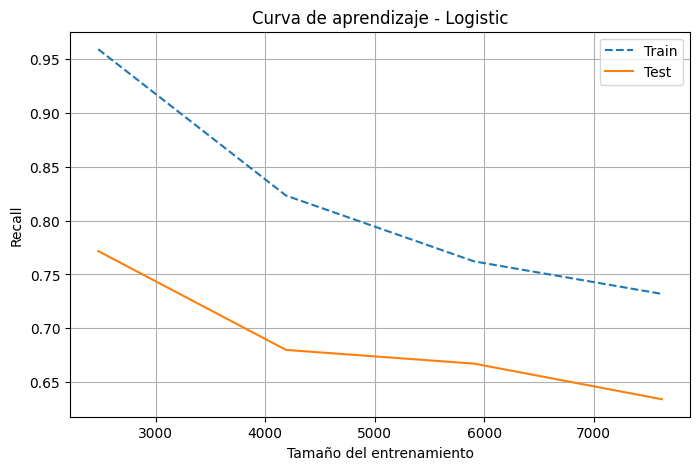

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\u

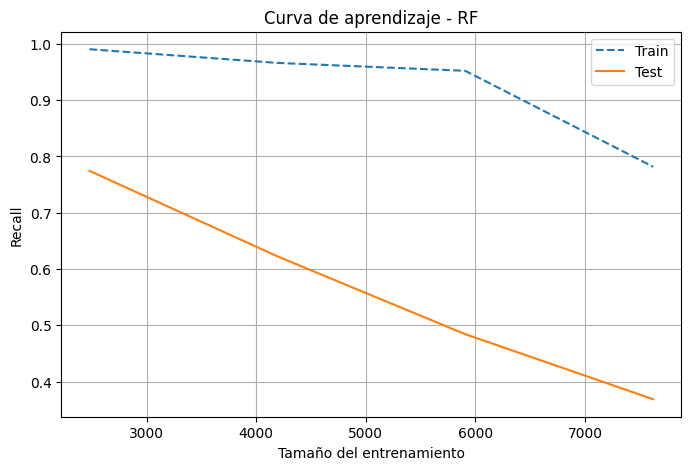

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\u

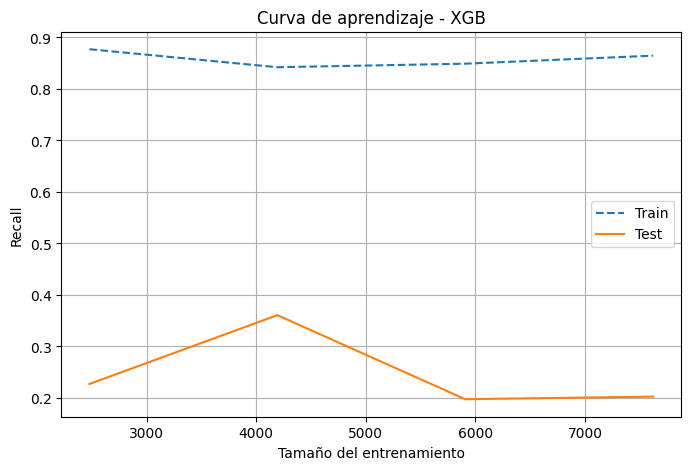

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\u

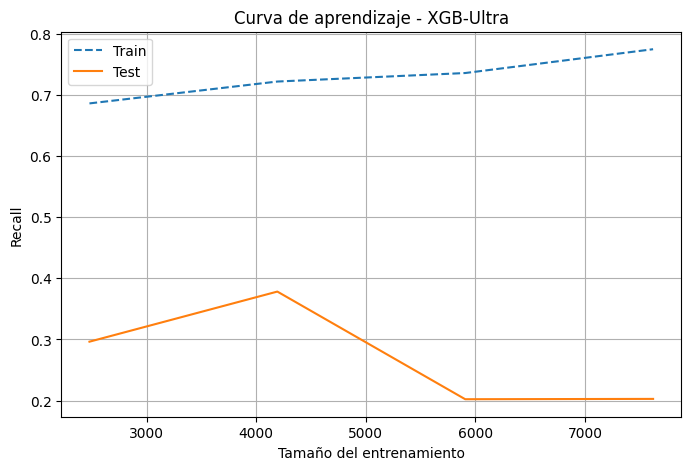

In [29]:
curva_aprendizaje(modelos_features, X1, y)

#### Usando el conjunto de variables con mayoria 

Como podemos observar el comportamiento es muy parecido al gurpo de variables anteriores

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\pipeline.py", line 475, in fit
    self._final_estimator.fit(Xt, y, 

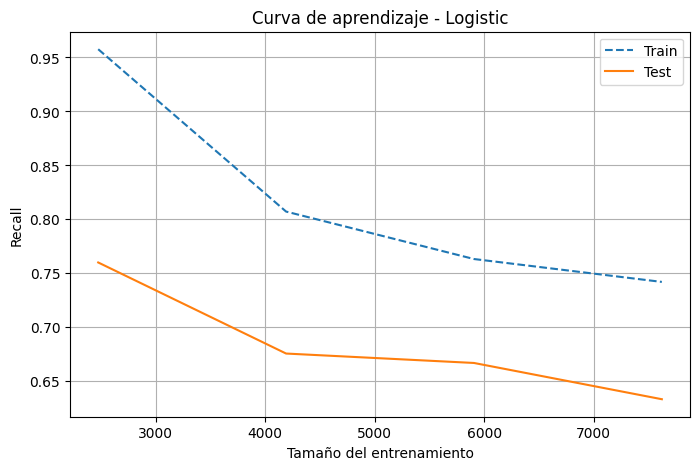

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\u

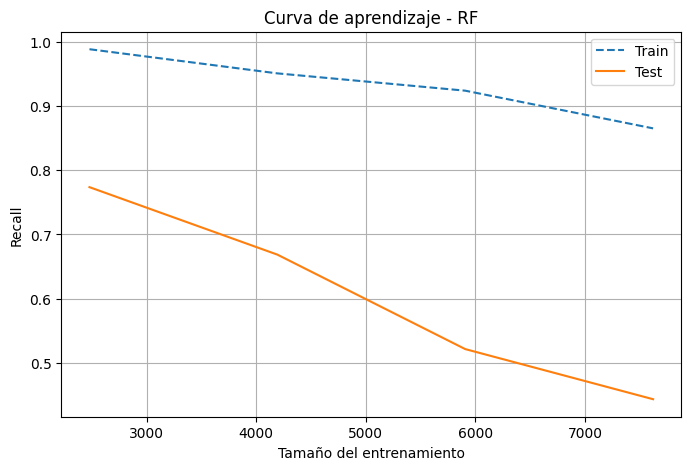

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\u

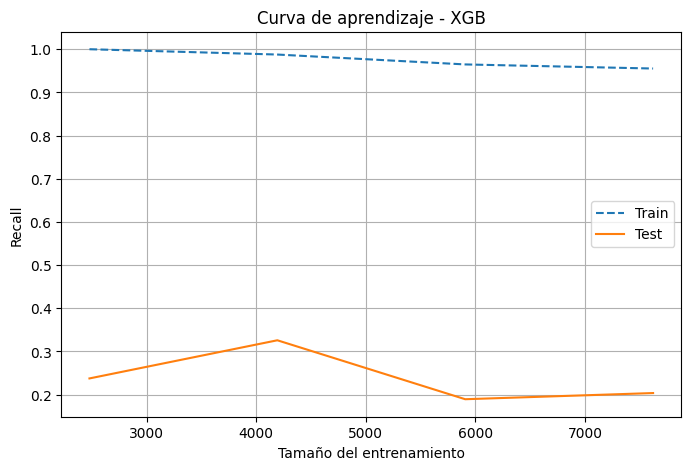

c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\metrics\_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\Asus\anaconda3\envs\Prueba\lib\site-packages\sklearn\u

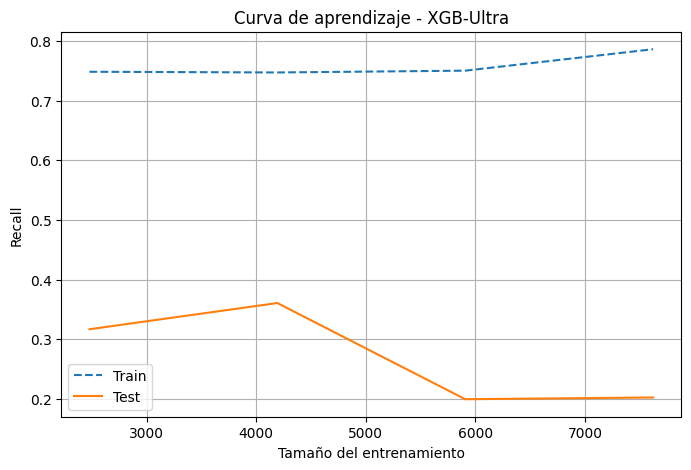

In [30]:
curva_aprendizaje(modelos_features, X2, y)

<!-- Como podemos observar, el comportamiento es muy parecido al del grupo de variables anteriores, de forma que casi se pueden sacar las mismas conclusiones. -->

Como podemos observar, el comportamiento es muy parecido al del grupo de variables anteriores, de forma que casi se pueden sacar las mismas conclusiones.

### Residuales

In [31]:
def analizar_residuales(model, X_test, y_test, nombre):

    #Probabilidades
    y_prob = model.predict_proba(X_test)[:, 1]

    #Residuales (observado - predicho)
    residuals = y_test - y_prob

    # Q-Q Plot
    plt.figure()
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot - {nombre}")
    plt.grid()
    plt.show()


    # Residual vs Probabilidad
    plt.figure()
    plt.scatter(y_prob, residuals, alpha=0.5)
    plt.axhline(0)
    plt.xlabel("Probabilidad predicha")
    plt.ylabel("Residual")
    plt.title(f"Residual vs Probabilidad - {nombre}")
    plt.grid()
    plt.show()


    #  Evaluación por thresholds
    print("\nMATRICES DE CONFUSIÓN")

    for t in [0.2, 0.5, 0.6, 0.7]:
        y_pred = (y_prob > t).astype(int)
        cm = confusion_matrix(y_test, y_pred)

        print(f"\nThreshold {t}")
        print(cm)


    # Optimización por costo

    cost_fp = 1   # falso positivo
    cost_fn = 3   # falso negativo

    best_t = 0
    best_cost = float('inf')

    for t in np.linspace(0, 1, 100):
        y_pred = (y_prob >= t).astype(int)

        fp = ((y_pred == 1) & (y_test == 0)).sum()
        fn = ((y_pred == 0) & (y_test == 1)).sum()

        cost = fp * cost_fp + fn * cost_fn

        if cost < best_cost:
            best_cost = cost
            best_t = t

    print("\nOPTIMIZACIÓN")
    print("Best threshold:", round(best_t, 3))
    print("Min cost:", best_cost)

In [32]:
def analizar_residuales_todos(modelos, X_train, y_train, X_test, y_test):

    for nombre, model in modelos.items():

        print("\n" + "="*50)
        print(f"Modelo: {nombre}")
        print("="*50)

        model.fit(X_train, y_train)

        analizar_residuales(model, X_test, y_test, nombre)

In [33]:
X_full_train, X_full_test, y_full_train, y_full_test = split_data(X_full, y)
X1_train, X1_test, y1_train, y1_test = split_data(X1, y)
X2_train, X2_test, y2_train, y2_test = split_data(X2, y)


Modelo: Logistic


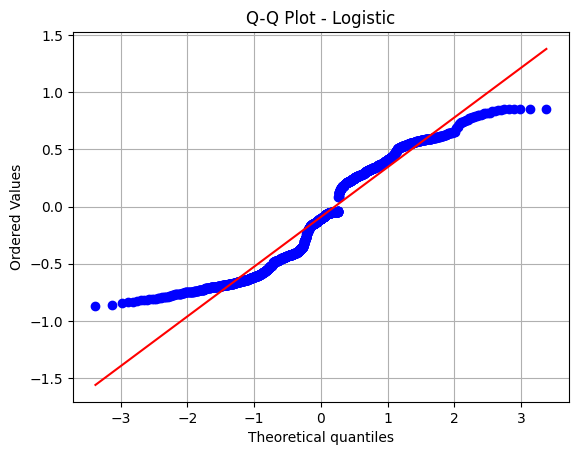

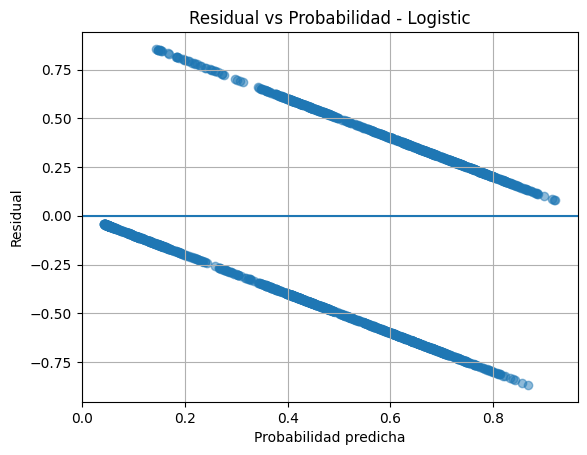


MATRICES DE CONFUSIÓN

Threshold 0.2
[[339 811]
 [ 17 739]]

Threshold 0.5
[[700 450]
 [241 515]]

Threshold 0.6
[[816 334]
 [311 445]]

Threshold 0.7
[[1036  114]
 [ 481  275]]

OPTIMIZACIÓN
Best threshold: 0.182
Min cost: 857

Modelo: RF


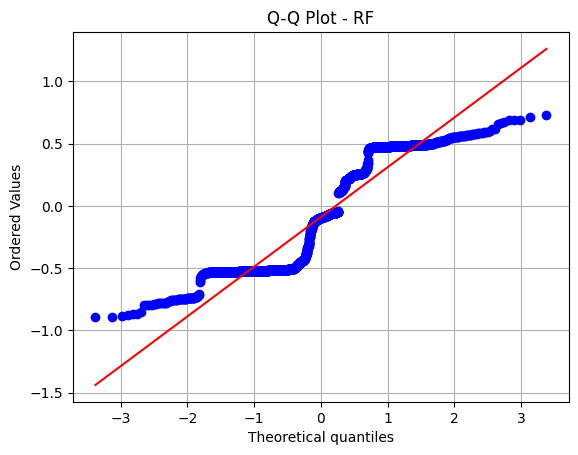

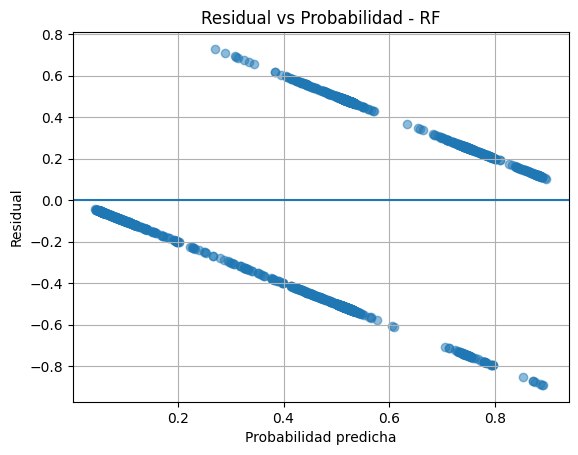


MATRICES DE CONFUSIÓN

Threshold 0.2
[[315 835]
 [  0 756]]

Threshold 0.5
[[486 664]
 [ 90 666]]

Threshold 0.6
[[1083   67]
 [ 459  297]]

Threshold 0.7
[[1085   65]
 [ 470  286]]

OPTIMIZACIÓN
Best threshold: 0.404
Min cost: 812

Modelo: XGB


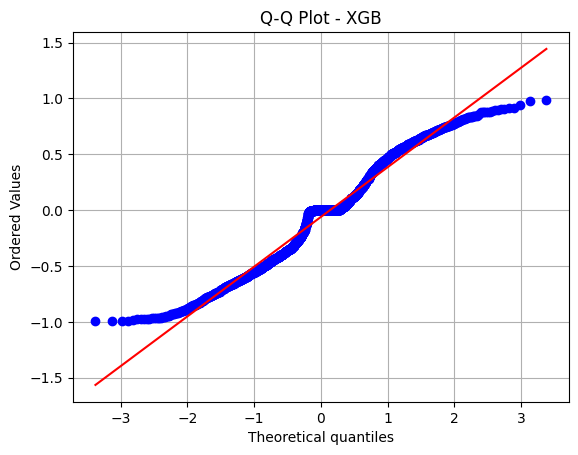

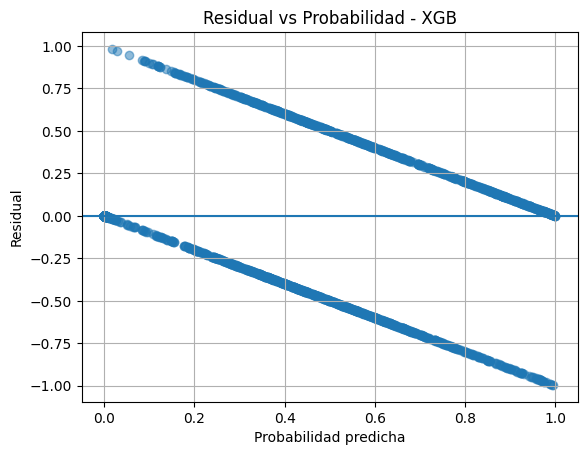


MATRICES DE CONFUSIÓN

Threshold 0.2
[[397 753]
 [ 36 720]]

Threshold 0.5
[[774 376]
 [274 482]]

Threshold 0.6
[[903 247]
 [372 384]]

Threshold 0.7
[[1009  141]
 [ 447  309]]

OPTIMIZACIÓN
Best threshold: 0.071
Min cost: 809

Modelo: XGB-Ultra


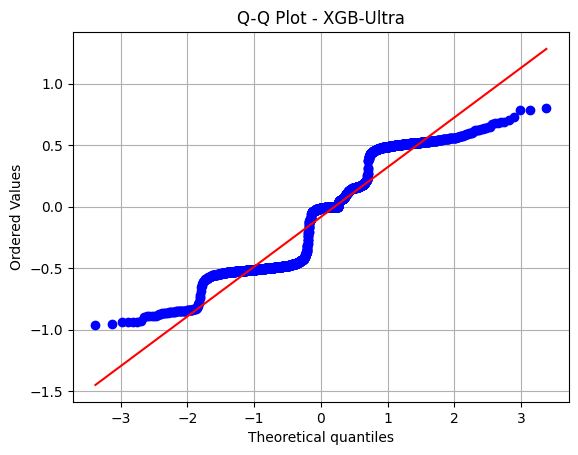

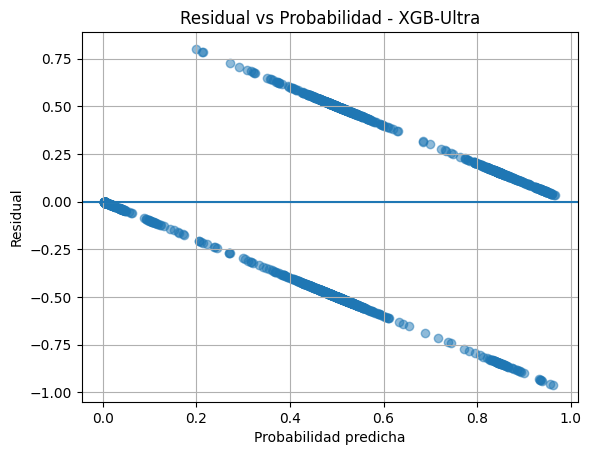


MATRICES DE CONFUSIÓN

Threshold 0.2
[[336 814]
 [  1 755]]

Threshold 0.5
[[723 427]
 [241 515]]

Threshold 0.6
[[1073   77]
 [ 449  307]]

Threshold 0.7
[[1082   68]
 [ 459  297]]

OPTIMIZACIÓN
Best threshold: 0.182
Min cost: 814


In [34]:
analizar_residuales_todos(modelos_features, X_full_train, y_full_train, X_full_test, y_full_test)


Modelo: Logistic


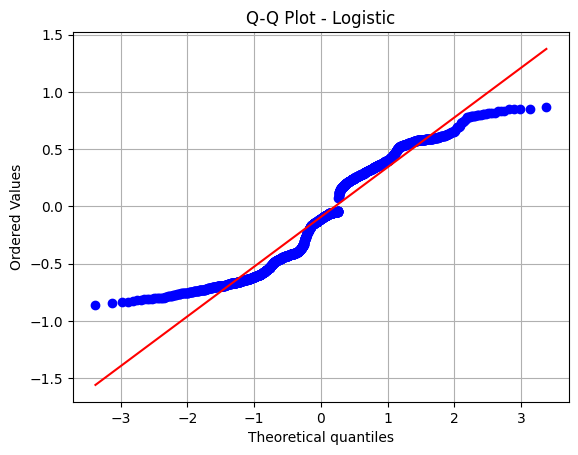

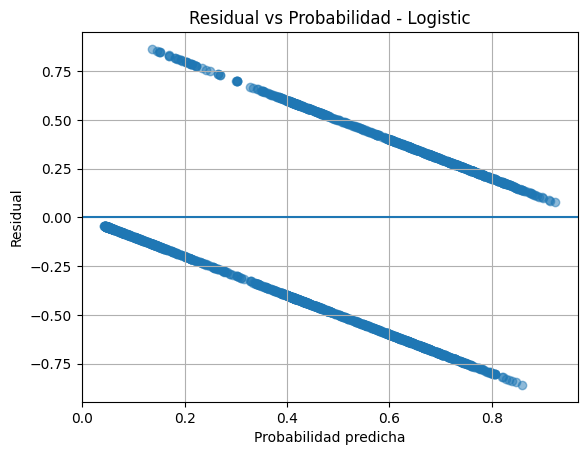


MATRICES DE CONFUSIÓN

Threshold 0.2
[[328 822]
 [ 15 741]]

Threshold 0.5
[[699 451]
 [239 517]]

Threshold 0.6
[[817 333]
 [301 455]]

Threshold 0.7
[[1038  112]
 [ 481  275]]

OPTIMIZACIÓN
Best threshold: 0.182
Min cost: 863

Modelo: RF


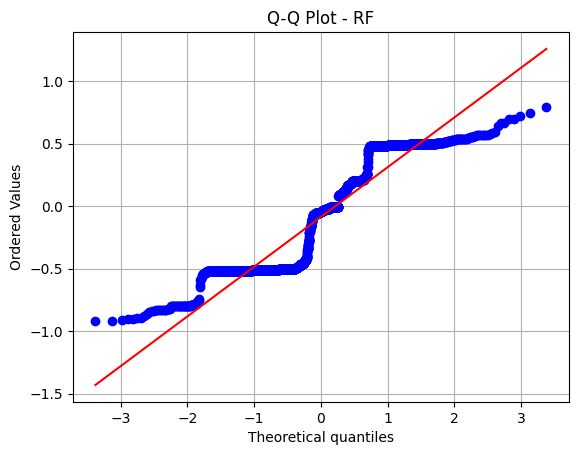

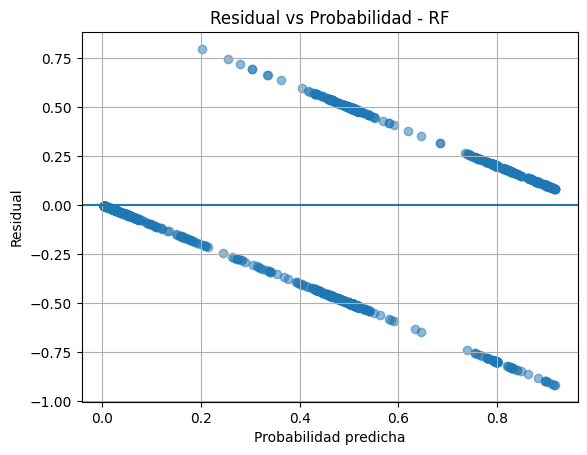


MATRICES DE CONFUSIÓN

Threshold 0.2
[[325 825]
 [  0 756]]

Threshold 0.5
[[486 664]
 [ 86 670]]

Threshold 0.6
[[1083   67]
 [ 459  297]]

Threshold 0.7
[[1085   65]
 [ 463  293]]

OPTIMIZACIÓN
Best threshold: 0.404
Min cost: 818

Modelo: XGB


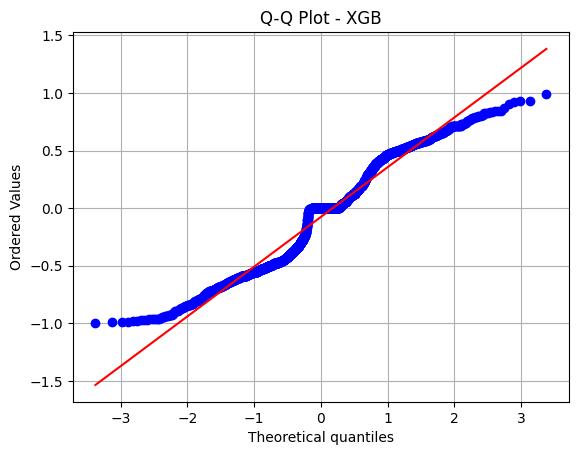

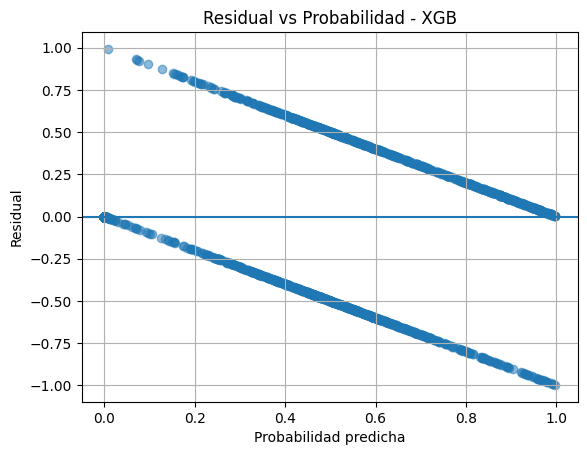


MATRICES DE CONFUSIÓN

Threshold 0.2
[[367 783]
 [ 17 739]]

Threshold 0.5
[[723 427]
 [230 526]]

Threshold 0.6
[[936 214]
 [375 381]]

Threshold 0.7
[[1039  111]
 [ 452  304]]

OPTIMIZACIÓN
Best threshold: 0.061
Min cost: 810

Modelo: XGB-Ultra


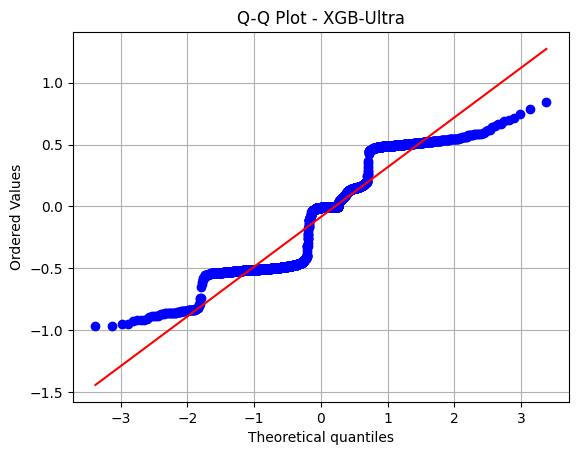

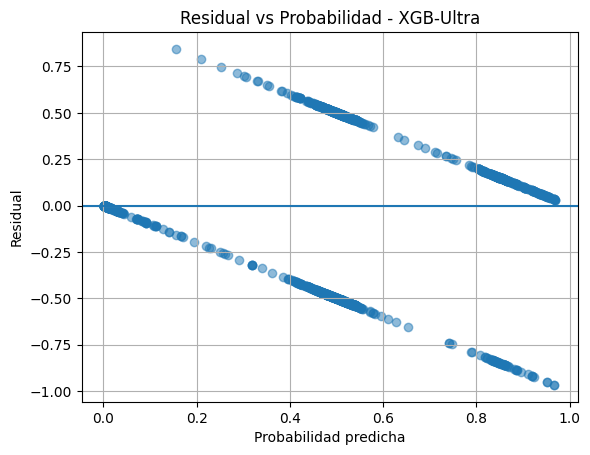


MATRICES DE CONFUSIÓN

Threshold 0.2
[[340 810]
 [  1 755]]

Threshold 0.5
[[710 440]
 [211 545]]

Threshold 0.6
[[1078   72]
 [ 453  303]]

Threshold 0.7
[[1081   69]
 [ 457  299]]

OPTIMIZACIÓN
Best threshold: 0.273
Min cost: 812


In [35]:
analizar_residuales_todos(modelos_features, X1_train, y1_train, X1_test, y1_test)


Modelo: Logistic


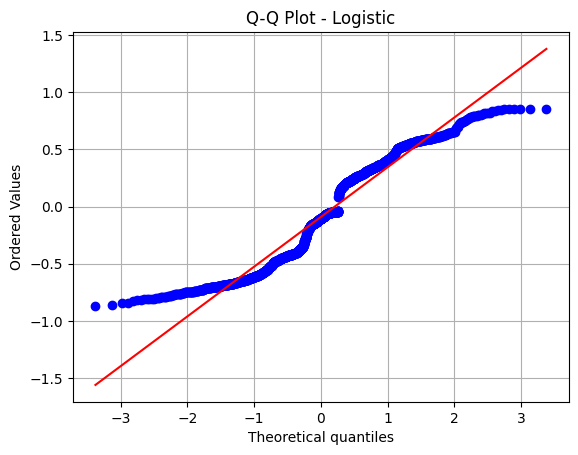

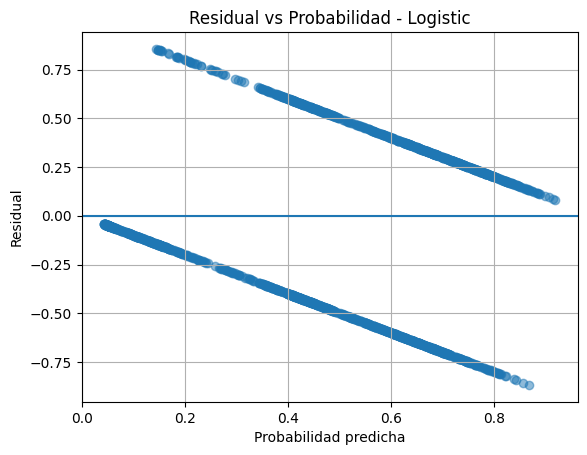


MATRICES DE CONFUSIÓN

Threshold 0.2
[[338 812]
 [ 16 740]]

Threshold 0.5
[[700 450]
 [243 513]]

Threshold 0.6
[[816 334]
 [309 447]]

Threshold 0.7
[[1037  113]
 [ 480  276]]

OPTIMIZACIÓN
Best threshold: 0.182
Min cost: 857

Modelo: RF


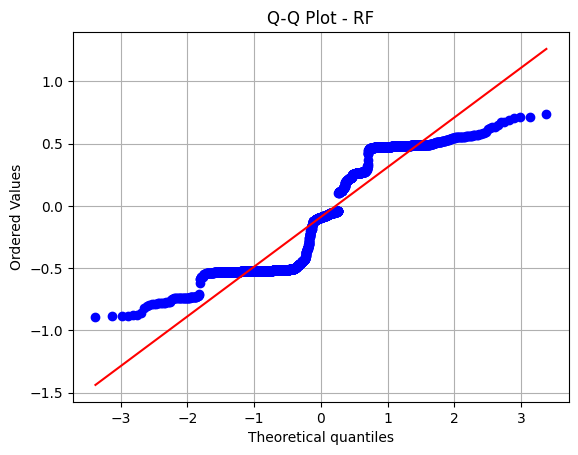

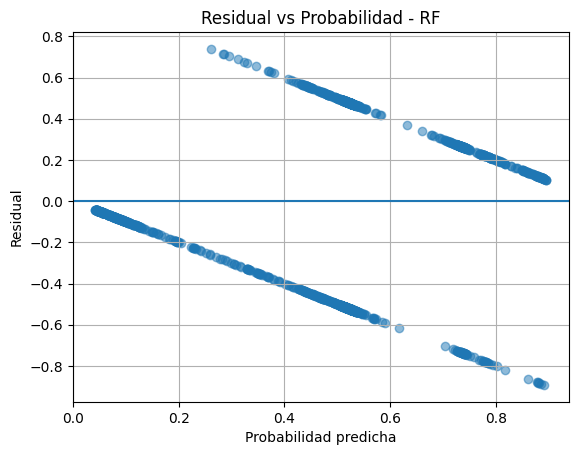


MATRICES DE CONFUSIÓN

Threshold 0.2
[[315 835]
 [  0 756]]

Threshold 0.5
[[488 662]
 [ 90 666]]

Threshold 0.6
[[1084   66]
 [ 459  297]]

Threshold 0.7
[[1085   65]
 [ 467  289]]

OPTIMIZACIÓN
Best threshold: 0.364
Min cost: 815

Modelo: XGB


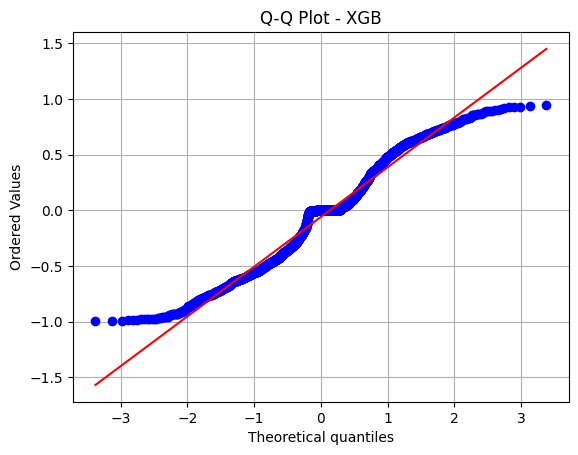

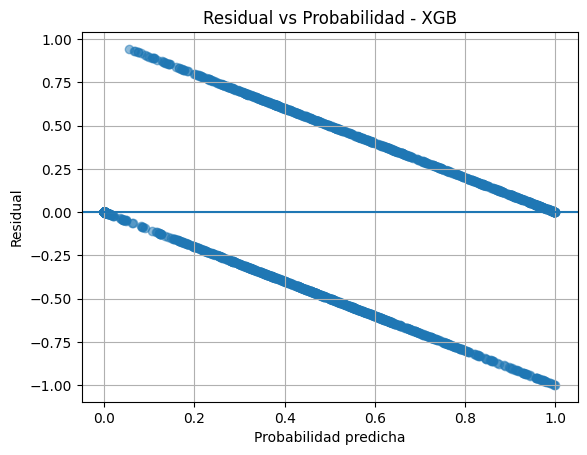


MATRICES DE CONFUSIÓN

Threshold 0.2
[[401 749]
 [ 34 722]]

Threshold 0.5
[[758 392]
 [285 471]]

Threshold 0.6
[[907 243]
 [370 386]]

Threshold 0.7
[[1013  137]
 [ 446  310]]

OPTIMIZACIÓN
Best threshold: 0.051
Min cost: 804

Modelo: XGB-Ultra


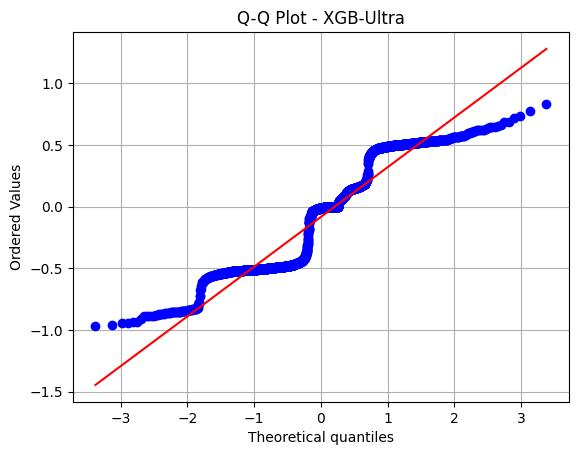

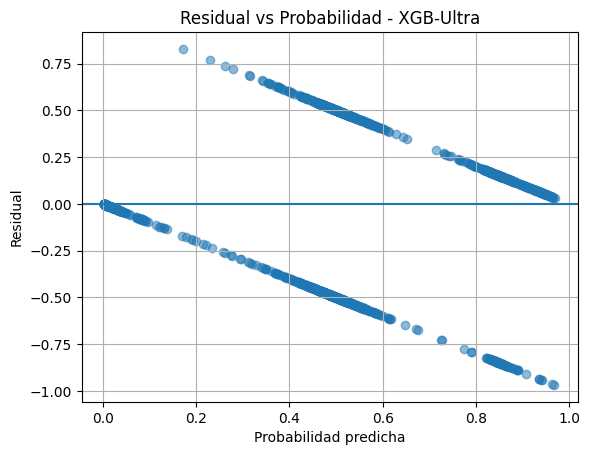


MATRICES DE CONFUSIÓN

Threshold 0.2
[[339 811]
 [  1 755]]

Threshold 0.5
[[733 417]
 [225 531]]

Threshold 0.6
[[1075   75]
 [ 450  306]]

Threshold 0.7
[[1083   67]
 [ 457  299]]

OPTIMIZACIÓN
Best threshold: 0.222
Min cost: 812


In [36]:
analizar_residuales_todos(modelos_features, X2_train, y2_train, X2_test, y2_test)

En el gráfico Q-Q, se muestran los valores de los residuales que tendrían si se distribuyeran de manera perfectamente normal están en el eje X (quantiles teóricos), mientras que el eje Y (valores ordenados) muestra los valores reales de los residuales organizados. Cuando los puntos azules se apartan de la línea roja, señala que los residuales no siguen una distribución normal, lo cual es habitual en modelos de clasificación.

Por su parte, el gráfico Residual vs Probabilidad predicha revela la manera en que los errores cambian de acuerdo a la probabilidad otorgada por el modelo. Un patrón óptimo sería que los residuos se distribuyan al azar en torno a cero, sin tendencias evidentes.

Análisis por modelo:

* Logistic Regression es el que presenta peor comportamiento: sus residuales muestran patrones marcados y fuertes desviaciones, indicando una calibración deficiente.
* Random Forest mejora respecto a la regresión logística, pero aún tiende a sobrestimar el riesgo en probabilidades altas.
* XGBoost muestra un comportamiento más estable y lineal.
* XGBoost-Ultra es el modelo que presenta los residuales mejor distribuidos y con menor cantidad de patrones sistemáticos, aunque todavía presenta algunas desviaciones en las colas (probabilidades muy bajas y muy altas).


Luego de observar cada uno de los threshold en cada grupo:

* 0.2 -> Predice muy bien para que no hayan clientes que no pagan y aparezcan que si, sin embargo la tasa de perder buenos clientes es muy alta
* 0.5 -> 542 muy alto
* 0.6 -> 471 es alto pero en general mejora mucho
* 0.7 -> se parece a 0.6 pero peor porque se equivoca más en los que son incumplidos y pone como cumplidos. Mejor que se descache en que son buenos y marca como malos y no al revés

Lo más conveniente para el negocio es utilizar un threshold entre 0.17 y 0.28.
En este rango se logra identificar mejor a los clientes que van a incumplir (nuestra target principal), minimizando el costo total de errores. aunque posiblemente perdamos buenos clientes.